<a href="https://www.kaggle.com/code/orestasdulinskas/auto-annotation-model?scriptVersionId=242546854" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Auto Annotation Model Training
---
## Data Preprocessing

In [4]:
import torch
from torch.utils.data import DataLoader, random_split, Dataset
from PIL import Image
import os
import json
import csv

# define class for loading and images and corresponding bounding box annotations
class TextDetectionDataset(Dataset):
    def __init__(self, csv_file, images_dir, transforms=None):
        self.images_dir = images_dir
        self.transforms = transforms
        self.data = []

        # load bounding box coordinates and text labels
        with open(csv_file, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            for row in reader:
                shape_attrs = json.loads(row["region_shape_attributes"])
                text_label_data = json.loads(row["region_attributes"])
                text_label = text_label_data.get("text", "")
                
                filename = row["filename"]
                
                x = shape_attrs["x"]
                y = shape_attrs["y"]
                w = shape_attrs["width"]
                h = shape_attrs["height"]

                self.data.append({
                    "filename": filename,
                    "bbox": [x, y, x + w, y + h],
                    "text": text_label
                })

        # structure image data with corresponding bounding boxes and labels
        self.image_data = {}
        for item in self.data:
            fname = item["filename"]
            if fname not in self.image_data:
                self.image_data[fname] = {
                    "filename": fname,
                    "boxes": [],
                    "labels": []
                }
            self.image_data[fname]["boxes"].append(item["bbox"])
            self.image_data[fname]["labels"].append(1) # 1 for "text" class
        
        self.image_keys = list(self.image_data.keys())

    def __len__(self):
        return len(self.image_keys)

    def __getitem__(self, idx):
        fname = self.image_keys[idx]
        img_path = os.path.join(self.images_dir, fname)

        # open image and convert to RGB
        img = Image.open(img_path).convert("RGB")

        # convert to tensors
        boxes = torch.tensor(self.image_data[fname]["boxes"], dtype=torch.float32)
        labels = torch.tensor(self.image_data[fname]["labels"], dtype=torch.int64)

        # target dict for evaluation
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["image_id"] = torch.tensor([idx])
        
        # ensure bounding boxes are valid: x2 > x1 and y2 > y1
        valid_boxes = []
        for i in range(boxes.shape[0]):
            x1, y1, x2, y2 = boxes[i]
            if x2 > x1 and y2 > y1:
                valid_boxes.append(i)
                
        # handle cases where no valid boxes exist after filtering
        if not valid_boxes: 
            print(f"Warning: No valid boxes for {fname}. Skipping this image.")
            return None, None # Return None to be filtered by collate_fn_custom
        else:
            target["boxes"] = boxes[valid_boxes]
            target["labels"] = labels[valid_boxes]

        # apply transformations
        if self.transforms:
            img = self.transforms(img)
            
        return img, target

In [5]:
import torchvision.transforms as T

# image augmentations
train_transforms =  T.Compose([
            T.RandomApply([T.ColorJitter(brightness=(0.6, 1.2), contrast=(0.5, 1))], p=0.7),
            T.RandomApply([T.GaussianBlur(kernel_size=(1,3))], p=0.3),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

In [6]:
# create the full dataset
full_dataset = TextDetectionDataset(
    csv_file='/kaggle/input/full-annotation-data/via_project_6Sep2024_20h21m_csv (1).csv',
    images_dir='/kaggle/input/complete-resized-journal-scans/resized_journal_scans'
)
len(full_dataset)

60

In [7]:
copy = full_dataset

# applying augmentations and concatinating
for _ in range(2):
    copy.transforms = train_transforms
    full_dataset = full_dataset + copy

len(full_dataset)

180

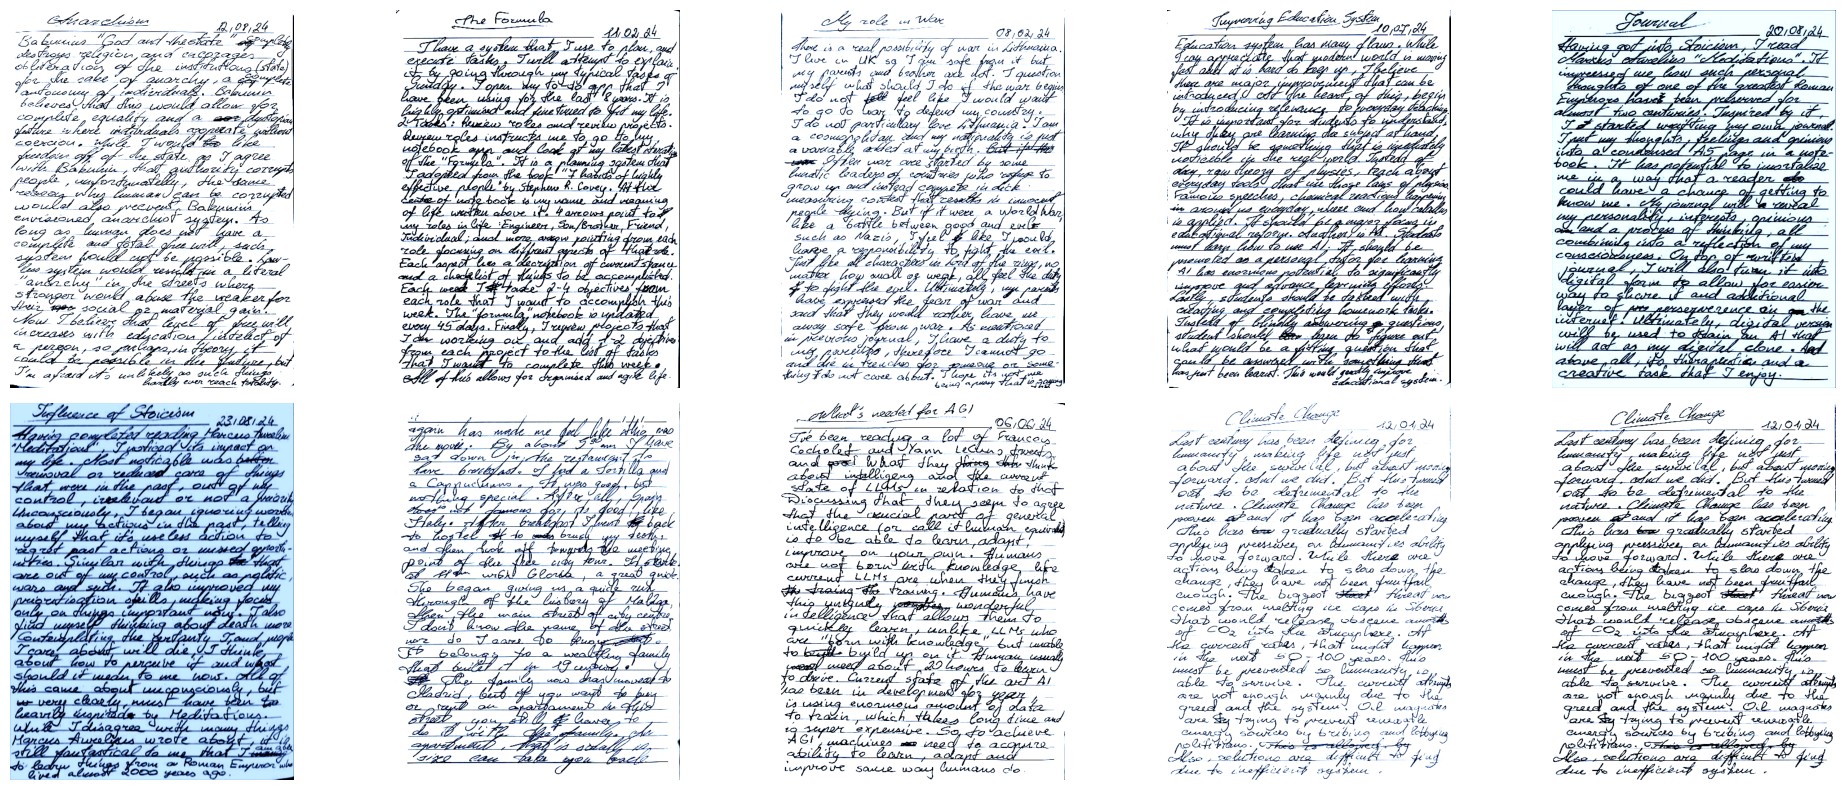

In [8]:
import matplotlib.pyplot as plt
import random

rows, cols = 2, 5
fig, axes = plt.subplots(rows, cols, figsize=(20, 8))

# random indices
indices = [random.randint(0, len(full_dataset) - 1) for _ in range(rows * cols)]

# plot image examples after augmentation
for ax, idx in zip(axes.flatten(), indices):
    img = full_dataset[idx][0].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [9]:
# split dataset
VAL_SPLIT = 0.3
dataset_size = len(full_dataset)
val_size = int(VAL_SPLIT * dataset_size)
train_size = dataset_size - val_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

In [10]:
# custom collate_fn
def collate_fn_custom(batch):
    batch = list(filter(lambda x: x[0] is not None, batch)) # filter out None items
    return list(zip(*batch))

In [11]:
# create dataloader instances
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn_custom, 
                          num_workers=min(8, os.cpu_count() or 4), persistent_workers=True, pin_memory=True, prefetch_factor=4)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn_custom, 
                        num_workers=min(8, os.cpu_count() or 4), persistent_workers=True, pin_memory=True, prefetch_factor=4)

print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

Training samples: 126, Validation samples: 54


## Training function

In [12]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

def train_model(model, train_loader, val_loader, optimizer, scaler, device, epochs):
    
    # log history
    train_losses_log = []
    val_map_log = []

    # initialize mAP metric
    map_metric = MeanAveragePrecision(iou_type="bbox").to(device)
    best_val_map = 0.0

    for epoch in range(epochs):
        # training phase
        model.train()
        epoch_train_loss = 0
        
        for batch_idx, (imgs, targets) in enumerate(train_loader):    
            # move to device
            imgs = [img.to(device, non_blocking=True) for img in imgs]
            targets = [{k: v.to(device, non_blocking=True) for k, v in t.items()} for t in targets]
            
            # filter out images with no valid targets
            valid_train_targets = []
            valid_train_imgs = []
            for i in range(len(targets)):
                if targets[i]['boxes'].shape[0] > 0:
                    valid_train_targets.append(targets[i])
                    valid_train_imgs.append(imgs[i])

            imgs = valid_train_imgs
            targets = valid_train_targets

            # enable mixed precision training
            with torch.amp.autocast('cuda'):
                loss_dict = model(imgs, targets)
                losses = sum(loss for loss in loss_dict.values())

            # backward pass and optimisation
            optimizer.zero_grad()
            scaler.scale(losses).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_train_loss += losses.item()
            
            # print progress every 5 batches
            if batch_idx % 5 == 0:
                 print(f"-- Epoch {epoch+1}/{epochs} | Batch {batch_idx}/{len(train_loader)} | Train Loss: {losses.item():.4f}")

        avg_epoch_train_loss = epoch_train_loss / len(train_loader) if len(train_loader) > 0 else 0
        train_losses_log.append(avg_epoch_train_loss)
        
        # validation phase
        model.eval()

        # reset metric state
        map_metric.reset()

        with torch.no_grad():
            for imgs_val, targets_val in val_loader:
                # move to device
                imgs_val = [img.to(device, non_blocking=True) for img in imgs_val]
                
                formatted_targets_val = []
                valid_indices_for_preds = []

                for i, t_val in enumerate(targets_val):
                    formatted_targets_val.append({
                        "boxes": t_val["boxes"].to(device),
                        "labels": t_val["labels"].to(device)
                    })
                    valid_indices_for_preds.append(i)
                
                imgs_val_filtered = [imgs_val[i] for i in valid_indices_for_preds]

                # prediction
                predictions = model(imgs_val_filtered)

                # update mAP
                map_metric.update(predictions, formatted_targets_val)

        # compute mAP
        val_map_results = map_metric.compute()
        current_val_map = val_map_results['map'].item()
        val_map_log.append(current_val_map)
        print(f"Epoch {epoch+1} | Train loss: {avg_epoch_train_loss:.4f} | Val mAP: {current_val_map:.4f}")

    return train_losses_log, val_map_log

## Model Setup

In [13]:
import torch.optim as optim
import torchvision

# set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.backends.cudnn.benchmark = True # cuDNN auto-tuner
torch.backends.cuda.matmul.allow_tf32 = True # allow TF32 precision for matmul
torch.backends.cudnn.allow_tf32 = True # allow TF32 precision for cuDNN

# load pre-trained model
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
num_classes = 2  # background + text

# set classification head to pre-trained model
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
model.to(device)

# initialise optimiser and scaler
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4) # AdamW is often preferred
scaler = torch.amp.GradScaler('cuda')

NUM_EPOCHS = 40

## Model Training

In [ ]:
# model training
train_losses, val_losses = train_model(model, train_loader, val_loader, optimizer, scaler, device, epochs=NUM_EPOCHS)

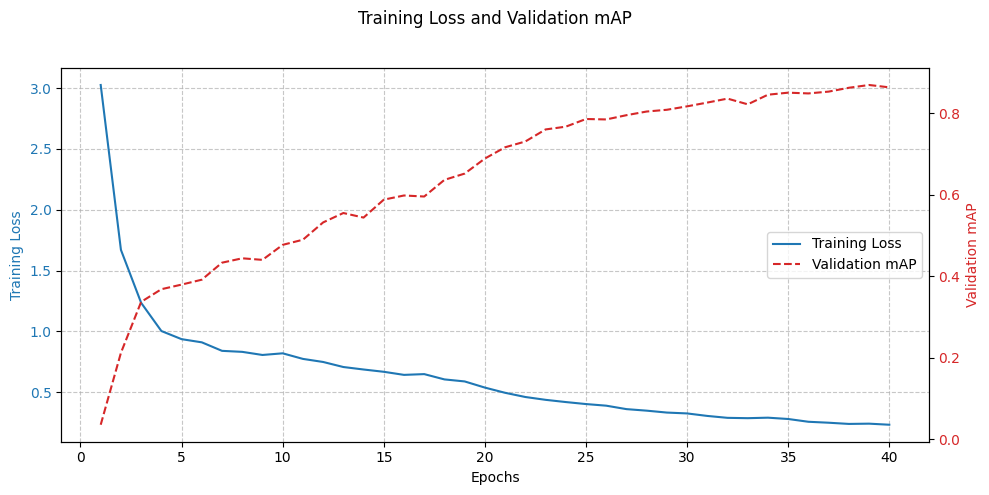

In [19]:
# plot training loss and validation mAP
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Training Loss', color=color)
ax1.plot(range(1, len(train_losses) + 1), train_losses, color=color, label='Training Loss')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.7)

# second axes that shares the same x-axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Validation mAP', color=color)
ax2.plot(range(1, len(val_losses) + 1), val_losses, color=color, linestyle='--', label='Validation mAP')
ax2.tick_params(axis='y', labelcolor=color)

fig.suptitle('Training Loss and Validation mAP')

# add legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='center right')

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Evaluation

In [20]:
import cv2

def predict_and_visualize(model, image_path, device, threshold=0.5):
    image = cv2.imread(image_path)

    orig_image = image.copy()
    
    transform = T.Compose([T.ToTensor()])
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        prediction = model(image_tensor)
    
    boxes = prediction[0]['boxes'].cpu().numpy()
    scores = prediction[0]['scores'].cpu().numpy()
    
    detected = False
    for i, box in enumerate(boxes):
        if scores[i] > threshold:
            detected = True
            x1, y1, x2, y2 = box.astype(int)
            cv2.rectangle(orig_image, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(orig_image, f"{scores[i]:.2f}", (x1, y1 - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(orig_image)
    plt.title(f"Predictions for {os.path.basename(image_path)}")
    plt.axis("off")
    plt.show()

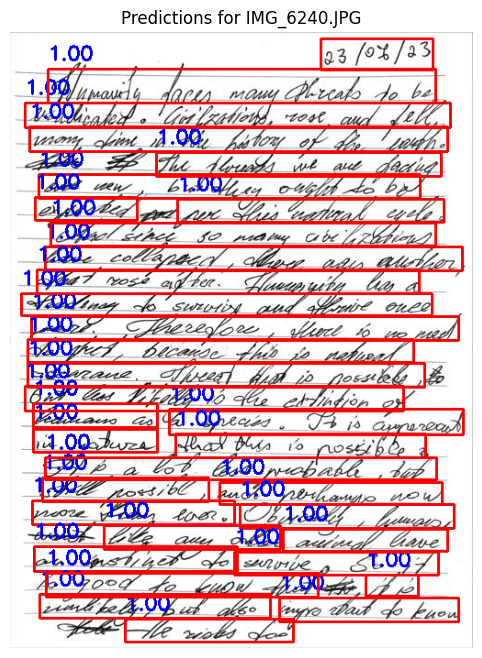

In [21]:
predict_and_visualize(model, '/kaggle/input/complete-resized-journal-scans/resized_journal_scans/IMG_6240.JPG', device=device, threshold=0.6)

In [22]:
torch.save(model.state_dict(), 'annotation_model.pth')